# Simulated Dyadic IBI Data

In this notebook, we generate three synthetic dyad recordings to demonstrate coupling, leader–follower dynamics,
and non-coupling in BioSync.
All simulated signals are derived from real IBI recordings so they retain physiological realism.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.signal import welch

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## Source data

We load person A's IBI series from a real recording. This is our **source signal**.
All simulated person-B series will be derived from it, ensuring the base physiology looks real.

In [2]:
def load_ibi(path, clip_ms=(300, 1000)):
    """Load IBI series from a xlsx file (sheet 'IBI Series').
    Row 0 is a segment marker and is skipped. Values outside clip_ms are removed."""
    df = pd.read_excel(path, sheet_name='IBI Series', header=None)
    ibi = df.iloc[1:, 0].astype(float).values
    lo, hi = clip_ms
    mask = (ibi >= lo) & (ibi <= hi)
    n_removed = (~mask).sum()
    if n_removed:
        print(f'  {path}: removed {n_removed} outlier(s) outside [{lo}, {hi}] ms')
    return ibi[mask]

ibi_a = load_ibi('dyad_recording/HRV_a.xlsx')
ibi_b_real = load_ibi('dyad_recording/HRV_b.xlsx')   # kept for reference / condition 3

MEAN_B = ibi_b_real.mean()   # target mean HR for simulated person B 

for name, ibi in [('A (source)', ibi_a), ('B (real, reference)', ibi_b_real)]:
    dur = ibi.sum() / 1000
    print(f'Person {name}: n={len(ibi):4d}  mean={ibi.mean():.1f} ms '
          f'({60000/ibi.mean():.1f} bpm)  SD={ibi.std():.1f} ms  '
          f'duration={dur:.0f} s ({dur/60:.1f} min)')

  dyad_recording/HRV_a.xlsx: removed 3 outlier(s) outside [300, 1000] ms
  dyad_recording/HRV_b.xlsx: removed 1 outlier(s) outside [300, 1000] ms
Person A (source): n= 541  mean=817.2 ms (73.4 bpm)  SD=84.6 ms  duration=442 s (7.4 min)
Person B (real, reference): n= 846  mean=644.7 ms (93.1 bpm)  SD=44.5 ms  duration=545 s (9.1 min)


---
## Condition 1 — Drifting Coupling

In this condition the two people start uncoupled, gradually synchronise in the middle of
the recording, and then drift apart again. In the windowed cross-correlation heatmap this should appear as a
saturated band centred on lag 0 that emerges and fades over time.

**Pipeline:**
1. Resample person A's IBI series to a uniform 5 Hz grid.
2. Generate an independent noise signal with the exact same power spectrum via phase randomisation.
3. Mix A's signal and the noise according to a smooth coupling envelope α(t).
4. Add a different mean heart rate so person B looks like a distinct individual.
5. Convert the continuous signal back to an event-based IBI series.

In [3]:
# ── Simulation parameters ──────────────────────────────────────────────
FS         = 5      # Re-sampling rate, hz  
ALPHA_MAX  = 0.90   # target peak coupling strength 
SEED       = 67     # fixed seed for reproducibility

### Step 1 — Resample to a uniform grid

IBI series are event-based: each value is the time between two beats, so the samples
are irregularly spaced in time. We use cubic spline interpolation to get a continuous
signal at a fixed 5 Hz rate.

In [4]:
def ibi_to_uniform(ibi_ms, fs=5):
    """Resample event-based IBI series to a uniform time grid via cubic spline.
    Returns (time_seconds, ibi_values_ms)."""
    ibi = np.asarray(ibi_ms, dtype=float)
    t_beat_ms = np.cumsum(np.insert(ibi, 0, 0)[:-1])   # beat onset times (ms)
    cs = CubicSpline(t_beat_ms, ibi)
    t_ms = np.arange(t_beat_ms[0], t_beat_ms[-1], 1000 / fs)
    return t_ms / 1000, cs(t_ms)   # seconds, ms

t_a, x_a = ibi_to_uniform(ibi_a, fs=FS)
N = len(x_a)

print(f'Resampled:  {N} samples  |  {t_a[-1]:.1f} s  |  '
      f'mean = {x_a.mean():.1f} ms  |  SD = {x_a.std():.1f} ms')

Resampled:  2207 samples  |  441.2 s  |  mean = 825.7 ms  |  SD = 82.2 ms


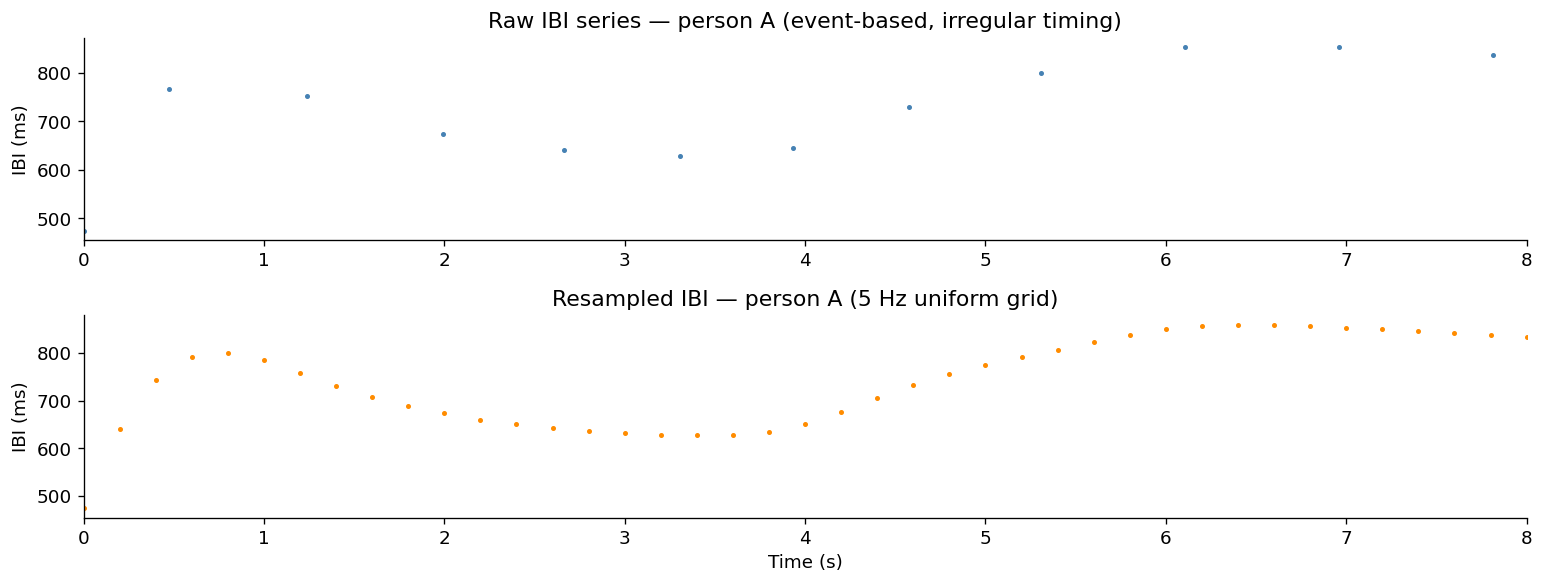

In [32]:
beat_t_a = np.cumsum(np.insert(ibi_a, 0, 0)[:-1]) / 1000   # beat-onset times in seconds

t_limit =  8  # length of displayed time series in seconds
t_a_crop = [val for val in t_a if val <= t_limit]
beat_t_a_crop = [val for val in beat_t_a if val <= t_limit]

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=False)

axes[0].plot(beat_t_a_crop, ibi_a[:len(beat_t_a_crop)], 'o', markersize=2, color='steelblue')
axes[0].set_ylabel('IBI (ms)')
axes[0].set_title('Raw IBI series — person A (event-based, irregular timing)')

axes[1].plot(t_a_crop, x_a[:len(t_a_crop)], 'o', markersize=2, color='darkorange')
axes[1].set_ylabel('IBI (ms)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'Resampled IBI — person A ({FS} Hz uniform grid)')

for ax in axes:
    ax.set_xlim(0, max(beat_t_a_crop[-1], t_a_crop[-1]))

plt.tight_layout()
plt.show()

### Step 2 — Phase-randomised surrogate (independent noise)

We need a noise signal that looks like a real HRV series — with the same or a similar spectral
shape and RSA peak — but is statistically independent of person A.

Phase randomisation achieves this: take the FFT of A’s signal, keep all the amplitudes
(which encode the spectrum) but replace every phase with a random angle. The result has
an identical power spectrum but little cross-correlation with A.

In [ ]:
def phase_randomize(signal, seed=None):
    """Generate a phase-randomised surrogate of a zero-mean signal.
    Preserves amplitude spectrum, destroys temporal structure."""
    rng = np.random.default_rng(seed)
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    amplitudes = np.abs(fft_vals)
    phases = rng.uniform(0, 2 * np.pi, len(fft_vals))
    phases[0] = 0                       # keep DC phase (zero mean)
    if N % 2 == 0:
        phases[-1] = 0                  # Nyquist must be real
    return np.fft.irfft(amplitudes * np.exp(1j * phases), n=N)

mean_a = x_a.mean()
x_a_fluct = x_a - mean_a               # zero-mean fluctuation

epsilon = phase_randomize(x_a_fluct, seed=SEED)

r_check = np.corrcoef(x_a_fluct, epsilon)[0, 1]
print(f'Cross-correlation A vs surrogate: r = {r_check:.4f}  (should be ≈ 0)')

Cross-correlation A vs surrogate: r = 0.0764  (should be ≈ 0)


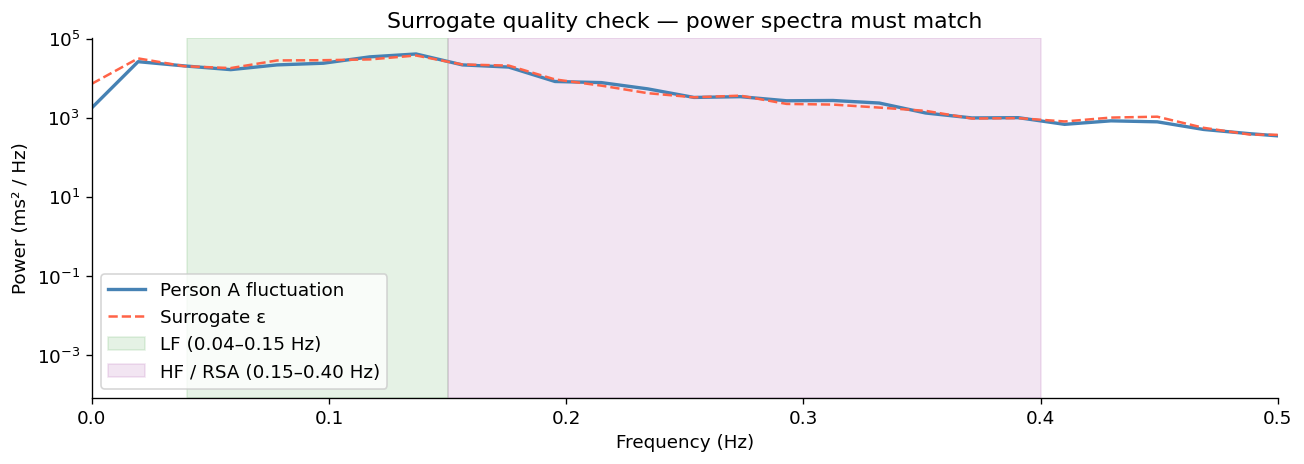

In [7]:
f_a, p_a = welch(x_a_fluct, fs=FS, nperseg=256)
f_eps, p_eps = welch(epsilon, fs=FS, nperseg=256)

fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogy(f_a,p_a, lw=2, color='steelblue', label='Person A fluctuation')
ax.semilogy(f_eps, p_eps, lw=1.5, color='tomato', linestyle='--', label='Surrogate ε')
ax.axvspan(0.04, 0.15, alpha=0.10, color='green',label='LF (0.04–0.15 Hz)')
ax.axvspan(0.15, 0.40, alpha=0.10, color='purple', label='HF / RSA (0.15–0.40 Hz)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (ms² / Hz)')
ax.set_xlim(0, 0.5)
ax.set_title('Surrogate quality check — power spectra must match')
ax.legend()
plt.tight_layout()
plt.show()

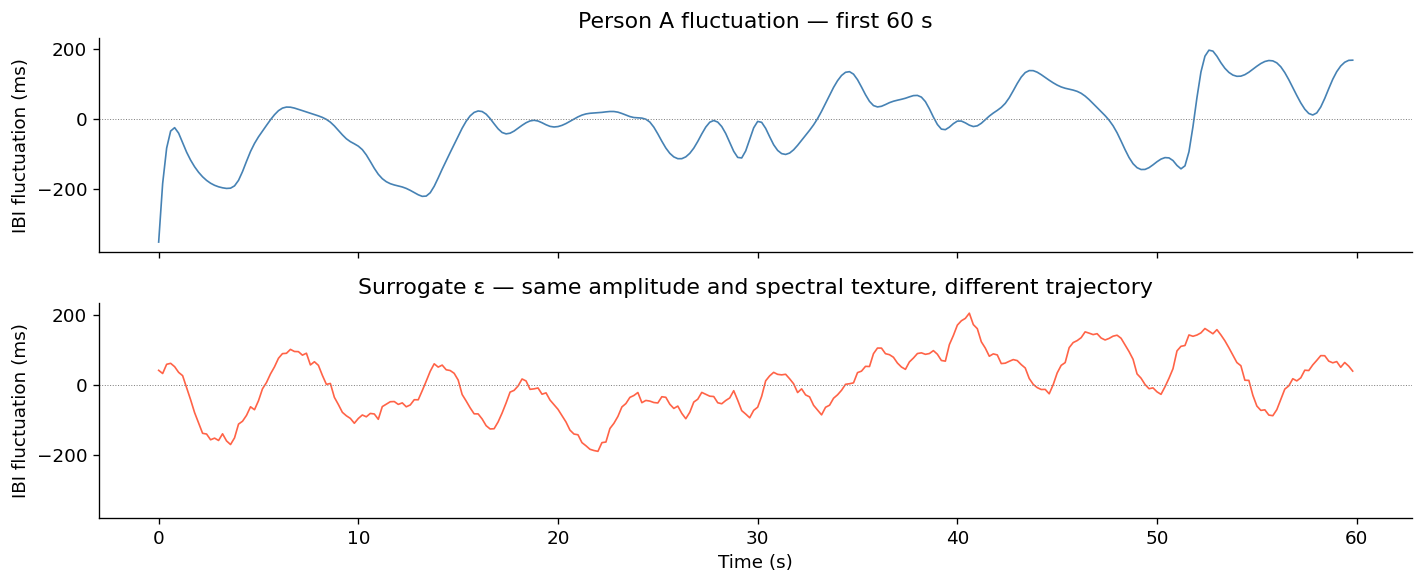

In [8]:
SHOW_S = 60
show_n = int(SHOW_S * FS)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, sharey=True)

axes[0].plot(t_a[:show_n], x_a_fluct[:show_n], lw=1.0, color='steelblue')
axes[0].axhline(0, color='gray', lw=0.6, linestyle=':')
axes[0].set_ylabel('IBI fluctuation (ms)')
axes[0].set_title('Person A fluctuation — first 60 s')

axes[1].plot(t_a[:show_n], epsilon[:show_n], lw=1.0, color='tomato')
axes[1].axhline(0, color='gray', lw=0.6, linestyle=':')
axes[1].set_ylabel('IBI fluctuation (ms)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Surrogate ε — same amplitude and spectral texture, different trajectory')

plt.tight_layout()
plt.show()

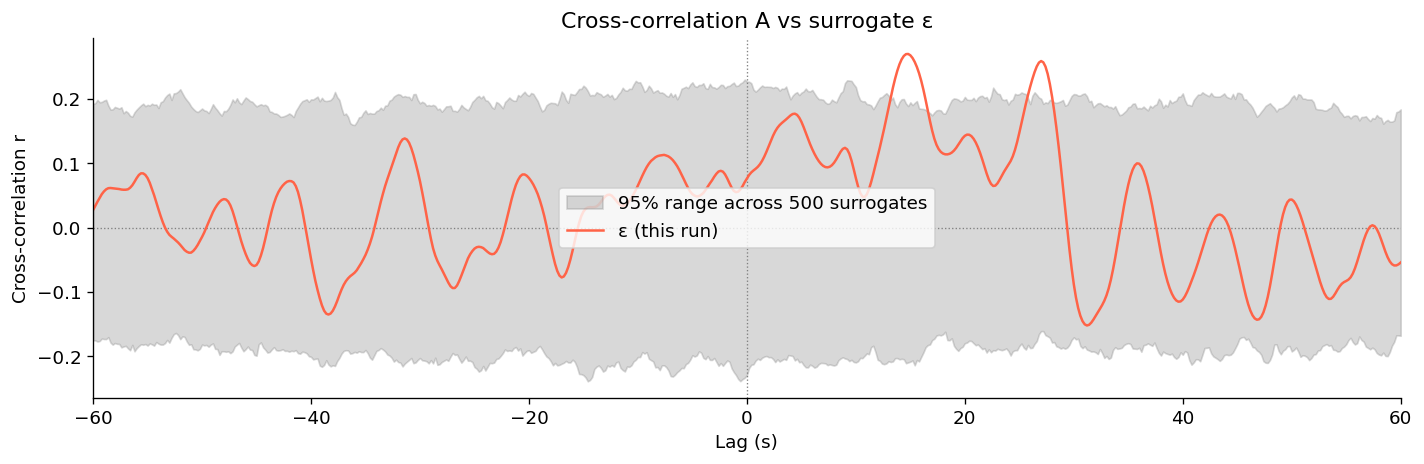

Max |r| for ε: 0.270  |  95% CI width at lag=0: ±0.229


In [ ]:
from scipy.signal import correlate

MAX_LAG_S = 60
max_lag_n = int(MAX_LAG_S * FS)

xa_z  = (x_a_fluct - x_a_fluct.mean()) / x_a_fluct.std()
eps_z = (epsilon    - epsilon.mean())   / epsilon.std()

# Cross-correlation of the actual surrogate with A
cc        = correlate(xa_z, eps_z, mode='full') / N
lags_full = np.arange(-(N - 1), N) / FS
mid       = N - 1
cc_trim   = cc[mid - max_lag_n : mid + max_lag_n + 1]
lags_trim = lags_full[mid - max_lag_n : mid + max_lag_n + 1]

# Bootstrap envelope: N independent surrogates show what "chance" looks like.
bootstrap_N = 500
rng_boot = np.random.default_rng(0)
cc_boot  = np.zeros((bootstrap_N, len(cc_trim)))
for i in range(bootstrap_N):
    eps_i   = phase_randomize(x_a_fluct, seed=int(rng_boot.integers(1_000_000)))
    eps_i_z = (eps_i - eps_i.mean()) / eps_i.std()
    cc_i    = correlate(xa_z, eps_i_z, mode='full') / N
    cc_boot[i] = cc_i[mid - max_lag_n : mid + max_lag_n + 1]

ci_lo = np.percentile(cc_boot, 2.5,  axis=0)
ci_hi = np.percentile(cc_boot, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(lags_trim, ci_lo, ci_hi, alpha=0.30, color='gray', label=f'95% range across {bootstrap_N} surrogates')
ax.axhline(0, color='gray', lw=0.8, linestyle=':')
ax.axvline(0, color='gray', lw=0.8, linestyle=':')
ax.plot(lags_trim, cc_trim, lw=1.5, color='tomato', label='ε (this run)')
ax.set_xlabel('Lag (s)')
ax.set_ylabel('Cross-correlation r')
ax.set_xlim(-MAX_LAG_S, MAX_LAG_S)
ax.set_title('Cross-correlation A vs surrogate ε')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Max |r| for ε: {np.max(np.abs(cc_trim)):.3f}  '
      f'|  95% CI width at lag=0: ±{max(abs(ci_lo[max_lag_n]), ci_hi[max_lag_n]):.3f}')

### Step 3 — Coupling envelope and mixing model

We control coupling strength with a time-varying weight α(t) ∈ [0, 1].
A Hanning window centred on the middle of the recording gives a smooth
onset and offset.

The mixed signal is:

> **B(t) = α(t) · A(t) + √(1 − α²(t)) · ε(t)**

The √(1 − α²) term keeps the variance of B constant regardless of α —
so the signal looks equally ‘active’ whether it is coupled or not.
When α = 0.9 at the peak, the expected Pearson r between A and B is 0.9.

Coupling active:  73 s → 368 s  (67% of recording, peak at 221 s)


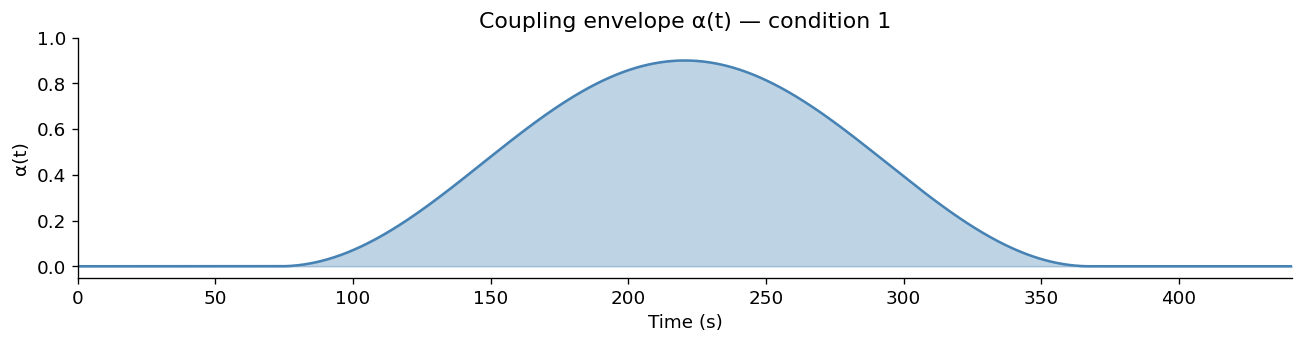

In [10]:
t_on  = N // 6
t_off = 5 * N // 6
win_len = t_off - t_on

alpha = np.zeros(N)
alpha[t_on:t_off] = np.hanning(win_len)
alpha *= ALPHA_MAX

print(f'Coupling active:  {t_a[t_on]:.0f} s → {t_a[t_off-1]:.0f} s  '
      f'({(t_off - t_on) / N * 100:.0f}% of recording, '
      f'peak at {t_a[(t_on + t_off)//2]:.0f} s)')

fig, ax = plt.subplots(figsize=(11, 3))
ax.fill_between(t_a, alpha, alpha=0.35, color='steelblue')
ax.plot(t_a, alpha, lw=1.5, color='steelblue')
ax.set_xlabel('Time (s)')
ax.set_ylabel('α(t)')
ax.set_ylim(-0.05, 1.0)
ax.set_xlim(0, t_a[-1])
ax.set_title('Coupling envelope α(t) — condition 1')
plt.tight_layout()
plt.show()

In [11]:
x_b_fluct = alpha * x_a_fluct + np.sqrt(1 - alpha**2) * epsilon

x_b = x_b_fluct + MEAN_B
x_b = np.clip(x_b, 300, 990) 

print(f'Person A:  mean = {x_a.mean():.1f} ms  ({60000/x_a.mean():.1f} bpm)  SD = {x_a.std():.1f} ms')
print(f'Person B:  mean = {x_b.mean():.1f} ms  ({60000/x_b.mean():.1f} bpm)  SD = {x_b.std():.1f} ms')

Person A:  mean = 825.7 ms  (72.7 bpm)  SD = 82.2 ms
Person B:  mean = 645.8 ms  (92.9 bpm)  SD = 81.2 ms


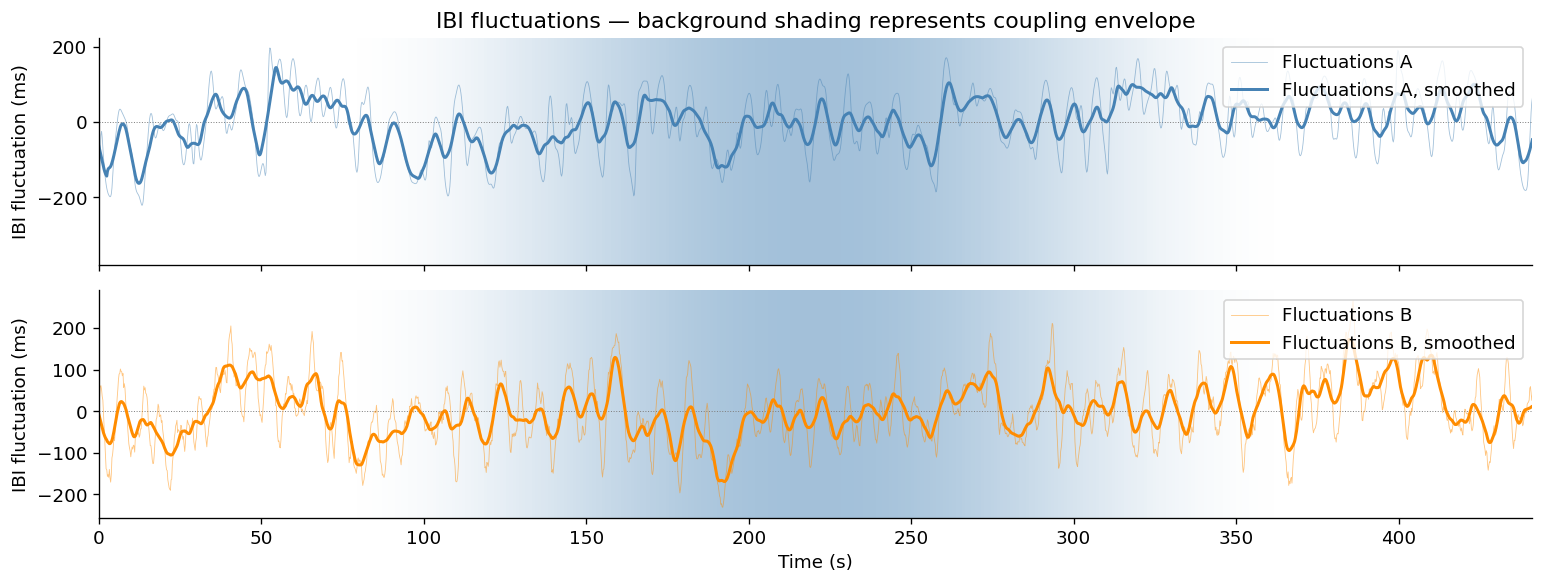

In [40]:
from matplotlib.transforms import blended_transform_factory
import matplotlib.colors as mcolors

def smooth(x, sec=5, fs=FS):
    k = int(sec * fs)
    return np.convolve(x, np.ones(k) / k, mode='same')

t_on_s  = t_a[t_on]
t_off_s = t_a[t_off - 1]

# Hanning-windowed shade: alpha 0 -> 0.5 -> 0 across the coupling region
_n = 300
_x_edges = np.linspace(t_on_s, t_off_s, _n + 1)
_hann_alpha = np.hanning(_n) * 0.5          # shape (n,), range 0-0.5
_r, _g, _b, _ = mcolors.to_rgba('steelblue')
_shade = np.zeros((1, _n, 4))
_shade[0, :, 0] = _r
_shade[0, :, 1] = _g
_shade[0, :, 2] = _b
_shade[0, :, 3] = _hann_alpha

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

for ax in axes:
    # x in data coords, y spans full axes height (0-1 in axes coords)
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    ax.pcolormesh(_x_edges, [0, 1], _shade, transform=trans, zorder=0, shading='flat')
    ax.axhline(0, color='gray', lw=0.6, linestyle=':')

axes[0].plot(t_a, x_a_fluct, lw=0.5, color='steelblue', alpha=0.5, label='Fluctuations A')
axes[0].plot(t_a, smooth(x_a_fluct), lw=1.8, color='steelblue', label='Fluctuations A, smoothed')
axes[0].set_ylabel('IBI fluctuation (ms)')
axes[0].set_title('IBI fluctuations — background shading represents coupling envelope')
axes[0].legend(loc='upper right')

axes[1].plot(t_a, x_b_fluct, lw=0.5, color='darkorange', alpha=0.5, label='Fluctuations B')
axes[1].plot(t_a, smooth(x_b_fluct), lw=1.8, color='darkorange', label='Fluctuations B, smoothed')
axes[1].set_ylabel('IBI fluctuation (ms)')
axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right')

for ax in axes:
    ax.set_xlim(0, t_a[-1])

plt.tight_layout()
plt.show()

### Step 4 — Rolling correlation preview

This is a simplified version of windowed cross-correlation - a preview of what BioSync will show at lag = 0.
We compute Pearson r in a sliding 60-second window and plot it against the coupling envelope. The two should track each other closely.

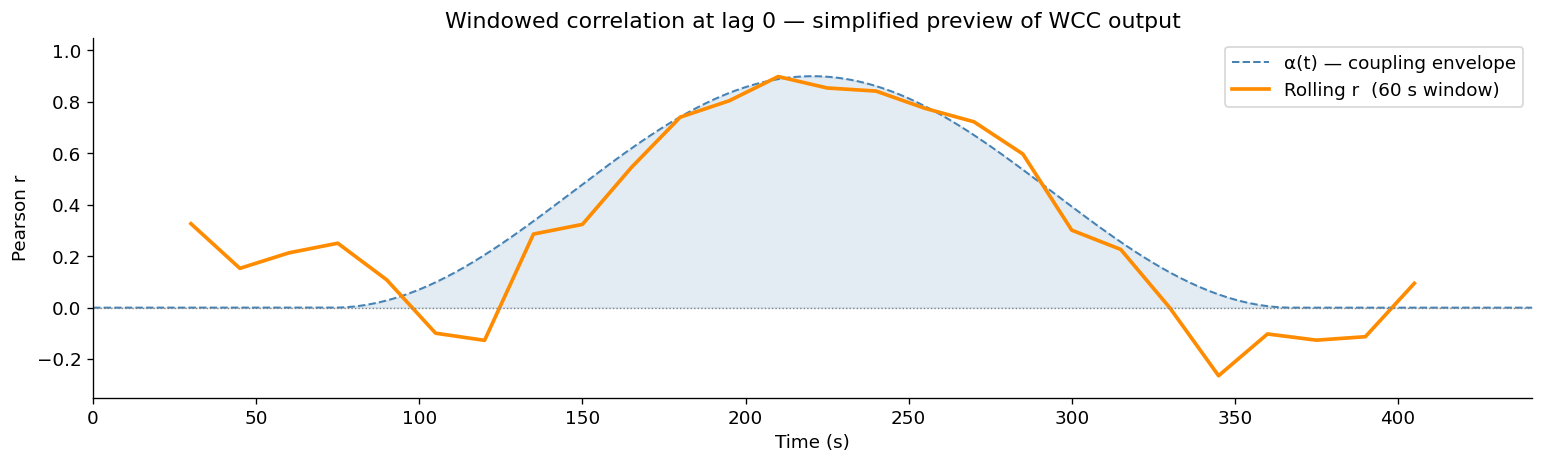

Peak rolling r = 0.90  |  mean r in uncoupled regions = 0.23


In [13]:
WIN_S  = 60
STEP_S = 15
win_n  = int(WIN_S  * FS)
step_n = int(STEP_S * FS)

centers, rs = [], []
for start in range(0, N - win_n, step_n):
    end = start + win_n
    r = np.corrcoef(x_a_fluct[start:end], x_b_fluct[start:end])[0, 1]
    centers.append(t_a[start + win_n // 2])
    rs.append(r)

centers = np.array(centers)
rs      = np.array(rs)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(t_a, alpha, alpha=0.15, color='steelblue')
ax.plot(t_a, alpha, lw=1.2, color='steelblue', linestyle='--', label='α(t) — coupling envelope')
ax.plot(centers, rs, lw=2.2, color='darkorange', label=f'Rolling r  ({WIN_S} s window)')
ax.axhline(0, color='gray', lw=0.8, linestyle=':')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pearson r')
ax.set_ylim(-0.35, 1.05)
ax.set_xlim(0, t_a[-1])
ax.set_title('Windowed correlation at lag 0 — simplified preview of WCC output')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Peak rolling r = {rs.max():.2f}  |  '
      f'mean r in uncoupled regions = {np.mean(rs[centers < t_on_s]):.2f}')

### Step 5 — Convert back to event-based IBIs

BioSync expects an event-based IBI series as input.
We recover beat times from the continuous signal by stepping forward iteratively:
the IBI at the current beat gives the time to the next beat.

In [14]:
def uniform_to_ibi(t_sec, x_ms, clip_ms=(300, 990)):
    """Convert a uniformly-sampled IBI signal back to an event-based IBI series.
    Iteratively steps forward: next_beat = current_beat + IBI(current_beat) / 1000."""
    cs = CubicSpline(t_sec, x_ms)
    t_max = t_sec[-1]
    lo, hi = clip_ms

    beat_times = [float(t_sec[0])]
    while True:
        t_curr = beat_times[-1]
        ibi_ms = float(np.clip(cs(t_curr), lo, hi))
        t_next = t_curr + ibi_ms / 1000
        if t_next >= t_max:
            break
        beat_times.append(t_next)

    return (np.diff(beat_times) * 1000).astype(float)   # ms

ibi_b_c1 = uniform_to_ibi(t_a, x_b)

dur_b = ibi_b_c1.sum() / 1000
print(f'Person B (event-based):  n = {len(ibi_b_c1)} beats  '
      f'| mean = {ibi_b_c1.mean():.1f} ms  '
      f'| SD = {ibi_b_c1.std():.1f} ms  '
      f'| duration = {dur_b:.0f} s ({dur_b/60:.1f} min)')
print(f'Person A (event-based):  n = {len(ibi_a)} beats  '
      f'| mean = {ibi_a.mean():.1f} ms  '
      f'| SD = {ibi_a.std():.1f} ms')

Person B (event-based):  n = 693 beats  | mean = 635.9 ms  | SD = 81.1 ms  | duration = 441 s (7.3 min)
Person A (event-based):  n = 541 beats  | mean = 817.2 ms  | SD = 84.6 ms


### Step 6 — Save

Each condition is saved using a pair of simple xlsx files.

In [15]:
import os

def save_condition(ibi_a_out, ibi_b_out, dirname):
    """Save a dyad as a subfolder of dyads_simulated/ with one xlsx per person.
    Format: header row, then [t_offset=0, ibi_1, ..., ibi_n]."""
    folder = f'dyads_simulated/{dirname}'
    os.makedirs(folder, exist_ok=True)
    for label, ibi in [('HRV_A', ibi_a_out), ('HRV_B', ibi_b_out)]:
        data = np.concatenate([[0.0], ibi.astype(float)])
        pd.DataFrame({'IBI_ms': data}).to_excel(
            f'{folder}/{label}.xlsx', index=False, sheet_name='IBI Series')
        print(f'Saved → {folder}/{label}.xlsx  ({len(ibi)} beats)')

save_condition(ibi_a, ibi_b_c1, 'cond1_drifting_coupling')

Saved → dyads_simulated/cond1_drifting_coupling/HRV_A.xlsx  (541 beats)
Saved → dyads_simulated/cond1_drifting_coupling/HRV_B.xlsx  (693 beats)


---
## Condition 2 — Leader-follower

In this condition person A consistently leads person B by a fixed time lag τ,
but the coupling itself emerges and disappears over the same segment as in condition 1.
In the windowed cross-correlation heatmap this should appear as a clearly visible saturated band that appears and fades
at a constant positive lag offset from the diagonal.

The mixing model uses the same Hanning envelope α(t) as condition 1, but person A's signal is shifted by τ before mixing:

> **B(t) = α(t) · A(t − τ) + √(1 − α²(t)) · ε(t)**

Outside the coupling window α = 0, so B is independent. Inside the window the lag-shifted A signal bleeds in with strength α(t).

In [16]:
LAG_S = 4.0               # A leads B by this many seconds
LAG_N = int(LAG_S * FS)  # same lag in samples (4 s × 5 Hz = 20 samples)

# Shift A forward by LAG_N samples: x_a_lagged[t] = x_a_fluct[t - LAG_N]
x_a_lagged = np.zeros(N)
x_a_lagged[LAG_N:] = x_a_fluct[:N - LAG_N]

# Same Hanning envelope as condition 1 — coupling active for the middle segment only
x_b_fluct_c2 = alpha * x_a_lagged + np.sqrt(1 - alpha**2) * epsilon
x_b_c2 = np.clip(x_b_fluct_c2 + MEAN_B, 300, 990)

print(f'Lag:      {LAG_S:.0f} s  ({LAG_N} samples at {FS} Hz)')
print(f'Coupling: {t_a[t_on]:.0f} s → {t_a[t_off-1]:.0f} s  (same window as condition 1)')
print(f'Person A: mean = {x_a.mean():.1f} ms  ({60000/x_a.mean():.1f} bpm)  SD = {x_a.std():.1f} ms')
print(f'Person B: mean = {x_b_c2.mean():.1f} ms  ({60000/x_b_c2.mean():.1f} bpm)  SD = {x_b_c2.std():.1f} ms')

Lag:      4 s  (20 samples at 5 Hz)
Coupling: 73 s → 368 s  (same window as condition 1)
Person A: mean = 825.7 ms  (72.7 bpm)  SD = 82.2 ms
Person B: mean = 645.4 ms  (93.0 bpm)  SD = 81.9 ms


### Signal comparison — the lag in the time domain

Zooming into the middle segment (where coupling is active) makes the lag visible by eye:
person B's fluctuations are a shifted copy of person A's, offset by τ seconds to the right.
Before and after the shaded window the two signals are unrelated.

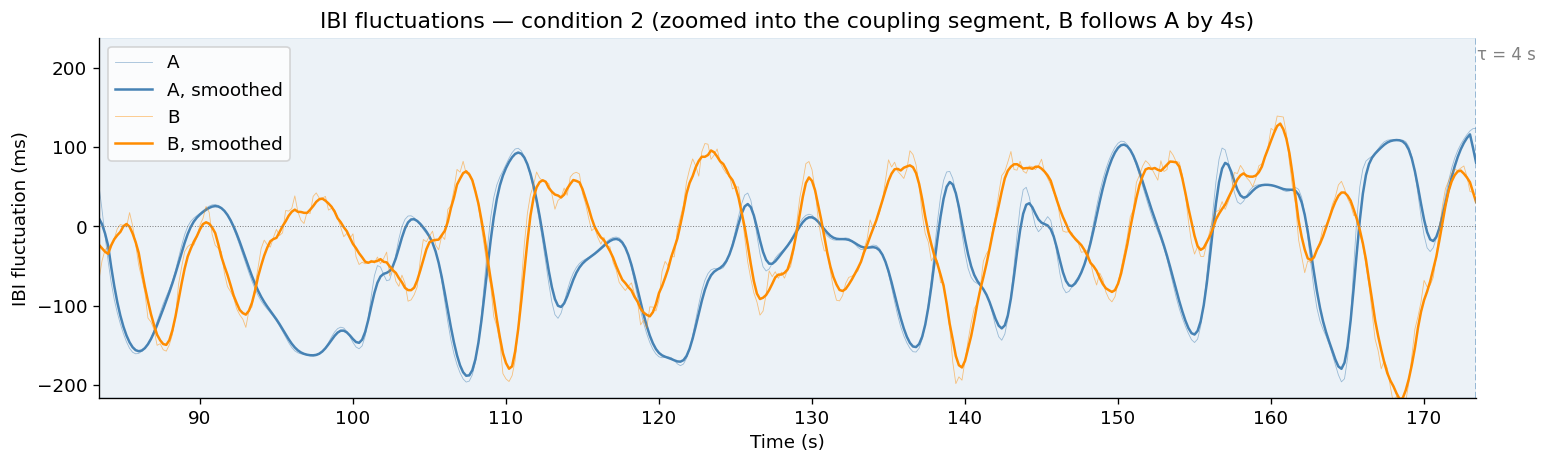

In [ ]:
# Zoom into the active coupling segment
ZOOM_START = t_on_s + 10   # just inside the window so coupling is already non-zero
ZOOM_END   = ZOOM_START + 90

mask = (t_a >= ZOOM_START) & (t_a <= ZOOM_END)
t_zoom = t_a[mask]

ymax = np.max(np.abs(x_a_fluct[mask])) * 1.1

fig, ax = plt.subplots(figsize=(13, 4))
ax.axvspan(t_on_s, t_off_s, alpha=0.10, color='steelblue', zorder=0)
ax.plot(t_zoom, x_a_fluct[mask], lw=.5, color='steelblue',  label='Fluctuations A', alpha=.5)
ax.plot(t_zoom, smooth(x_a_fluct[mask], 1.5), lw=1.5, color='steelblue',  label='Fluctuations A, smoothed')
ax.plot(t_zoom, x_b_fluct_c2[mask], lw=.5, color='darkorange', label='Fluctuations B', alpha=.5)
ax.plot(t_zoom, smooth(x_b_fluct_c2[mask], 1.5), lw=1.5, color='darkorange', label='Fluctuations B, smoothed')

# mark the highest peak in A and its echo in B
peak_t = t_zoom[np.argmax(x_a_fluct[mask])]
ax.axvline(peak_t,         color='steelblue',  lw=1.0, linestyle='--', alpha=0.6)
ax.axvline(peak_t + LAG_S, color='darkorange', lw=1.0, linestyle='--', alpha=0.6)
ax.annotate('', xy=(peak_t + LAG_S, ymax * 0.92), xytext=(peak_t, ymax * 0.92),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(peak_t + LAG_S / 2, ymax * 0.97,
        f'τ = {LAG_S:.0f} s', ha='center', color='gray', fontsize=10)

ax.axhline(0, color='gray', lw=0.6, linestyle=':')
ax.set_xlabel('Time (s)')
ax.set_ylabel('IBI fluctuation (ms)')
ax.set_xlim(ZOOM_START, ZOOM_END)
ax.set_ylim(-ymax, ymax * 1.1)
ax.set_title(f'IBI fluctuations — condition 2 (zoomed into the coupling segment, B follows A by {LAG_S:.0f}s)')
ax.legend()
plt.tight_layout()
plt.show()

### Rolling correlation at lag τ

The direct analog of condition 1's lag-0 rolling correlation, but now evaluated
at the expected leader-follower lag: we slide a 60-second window and compute
r(A[window], B[window + τ]).

When coupling is active this should track α(t). Outside the coupling window it
drops back to near zero — same as the lag-0 value would be throughout condition 3.

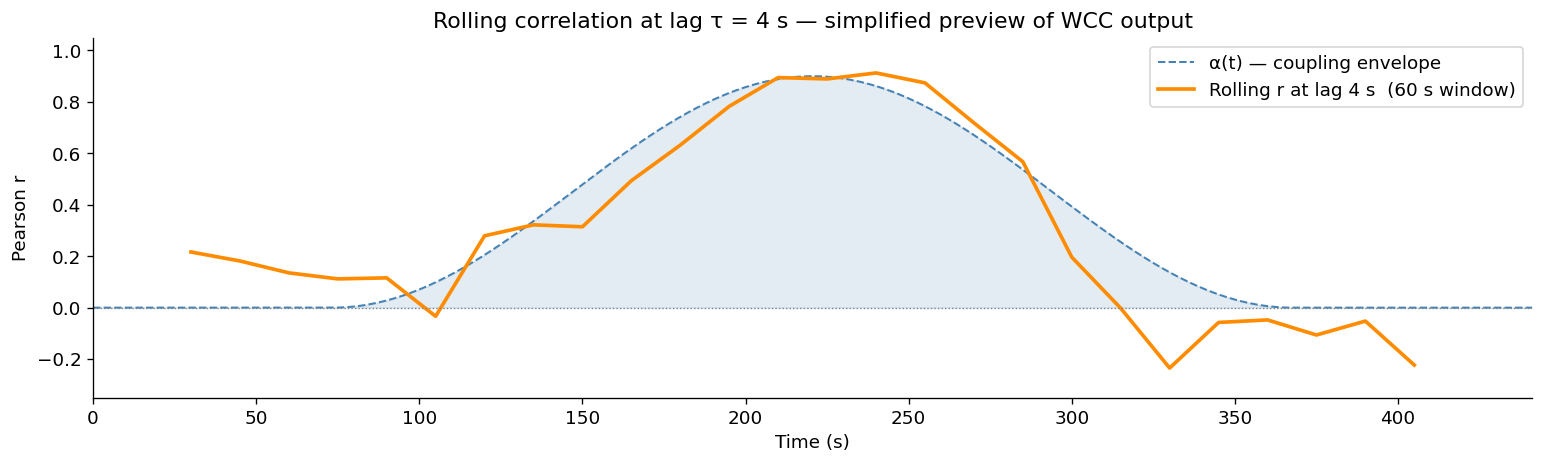

Peak rolling r at τ = 0.91  |  mean r outside coupling = 0.18


In [18]:
centers_c2, rs_c2 = [], []
for start in range(0, N - win_n - LAG_N, step_n):
    end = start + win_n
    # shift B forward by LAG_N so we evaluate at lag = +LAG_S
    r = np.corrcoef(x_a_fluct[start:end],
                    x_b_fluct_c2[start + LAG_N : end + LAG_N])[0, 1]
    centers_c2.append(t_a[start + win_n // 2])
    rs_c2.append(r)
centers_c2 = np.array(centers_c2)
rs_c2      = np.array(rs_c2)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(t_a, alpha, alpha=0.15, color='steelblue')
ax.plot(t_a, alpha, lw=1.2, color='steelblue', linestyle='--',
        label='α(t) — coupling envelope')
ax.plot(centers_c2, rs_c2, lw=2.2, color='darkorange',
        label=f'Rolling r at lag {LAG_S:.0f} s  ({WIN_S} s window)')
ax.axhline(0, color='gray', lw=0.8, linestyle=':')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pearson r')
ax.set_ylim(-0.35, 1.05)
ax.set_xlim(0, t_a[-1])
ax.set_title(f'Rolling correlation at lag τ = {LAG_S:.0f} s — simplified preview of WCC output')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Peak rolling r at τ = {rs_c2.max():.2f}  |  '
      f'mean r outside coupling = {np.mean(rs_c2[centers_c2 < t_on_s]):.2f}')

In [19]:
ibi_b_c2 = uniform_to_ibi(t_a, x_b_c2)

dur_b2 = ibi_b_c2.sum() / 1000
print(f'Person B (event-based):  n = {len(ibi_b_c2)} beats  '
      f'| mean = {ibi_b_c2.mean():.1f} ms  '
      f'| SD = {ibi_b_c2.std():.1f} ms  '
      f'| duration = {dur_b2:.0f} s ({dur_b2/60:.1f} min)')

save_condition(ibi_a, ibi_b_c2, 'cond2_leader_follower')

Person B (event-based):  n = 694 beats  | mean = 635.1 ms  | SD = 82.8 ms  | duration = 441 s (7.3 min)
Saved → dyads_simulated/cond2_leader_follower/HRV_A.xlsx  (541 beats)
Saved → dyads_simulated/cond2_leader_follower/HRV_B.xlsx  (694 beats)


---
## Condition 3 — No Coupling

In this condition the two people are completely independent:

1. **Different source recordings.** Person B is derived from `HRV_other.xlsx`, a recording from an entirely separate session with a different participant.

2. **Phase randomisation applied to B.** Person B's signal is phase-randomised before saving. This eliminates the chance of accidental correlation arising from shared recording conditions.

`HRV_other` is trimmed to match Person A's sample count N after resampling.

In the WCC heatmap this should appear as a uniformly dim, noisy surface at all lags and all time windows — the null baseline.

In [20]:
# ── Load independent recording (different session) ─────────────────────
ibi_other = load_ibi('dyad_recording/HRV_other.xlsx')
MEAN_OTHER = ibi_other.mean()
dur_other  = ibi_other.sum() / 1000
print(f'HRV_other:  n={len(ibi_other)}  mean={MEAN_OTHER:.1f} ms  '
      f'({60000/MEAN_OTHER:.1f} bpm)  dur={dur_other:.0f} s ({dur_other/60:.1f} min)')

# Resample to uniform grid, then trim (or tile) to match Person A's N samples
t_other_full, x_other_full = ibi_to_uniform(ibi_other, fs=FS)
if len(x_other_full) >= N:
    x_other = x_other_full[:N]
    print(f'HRV_other trimmed {len(x_other_full)} → {N} samples to match Person A')
else:
    reps    = int(np.ceil(N / len(x_other_full)))
    x_other = np.tile(x_other_full, reps)[:N]
    print(f'HRV_other tiled {len(x_other_full)} → {N} samples to match Person A')
x_other_fluct = x_other - x_other.mean()

# Phase-randomise B:
x_b_fluct_c3 = phase_randomize(x_other_fluct, seed=SEED + 3)

x_a_c3 = np.clip(x_a_fluct + x_a.mean(), 200, 1100)
x_b_c3 = np.clip(x_b_fluct_c3 + MEAN_OTHER,  200, 1100)

r_c3 = np.corrcoef(x_a_fluct, x_b_fluct_c3)[0, 1]
print(f'Person A: mean = {x_a_c3.mean():.1f} ms  ({60000/x_a_c3.mean():.1f} bpm)  SD = {x_a_c3.std():.1f} ms')
print(f'Person B: mean = {x_b_c3.mean():.1f} ms  ({60000/x_b_c3.mean():.1f} bpm)  SD = {x_b_c3.std():.1f} ms')
print(f'Global r (A vs B): {r_c3:.4f}  (expected ≈ 0)')

HRV_other:  n=697  mean=717.7 ms  (83.6 bpm)  dur=500 s (8.3 min)
HRV_other trimmed 2499 → 2207 samples to match Person A
Person A: mean = 825.7 ms  (72.7 bpm)  SD = 82.2 ms
Person B: mean = 717.7 ms  (83.6 bpm)  SD = 66.2 ms
Global r (A vs B): 0.0116  (expected ≈ 0)


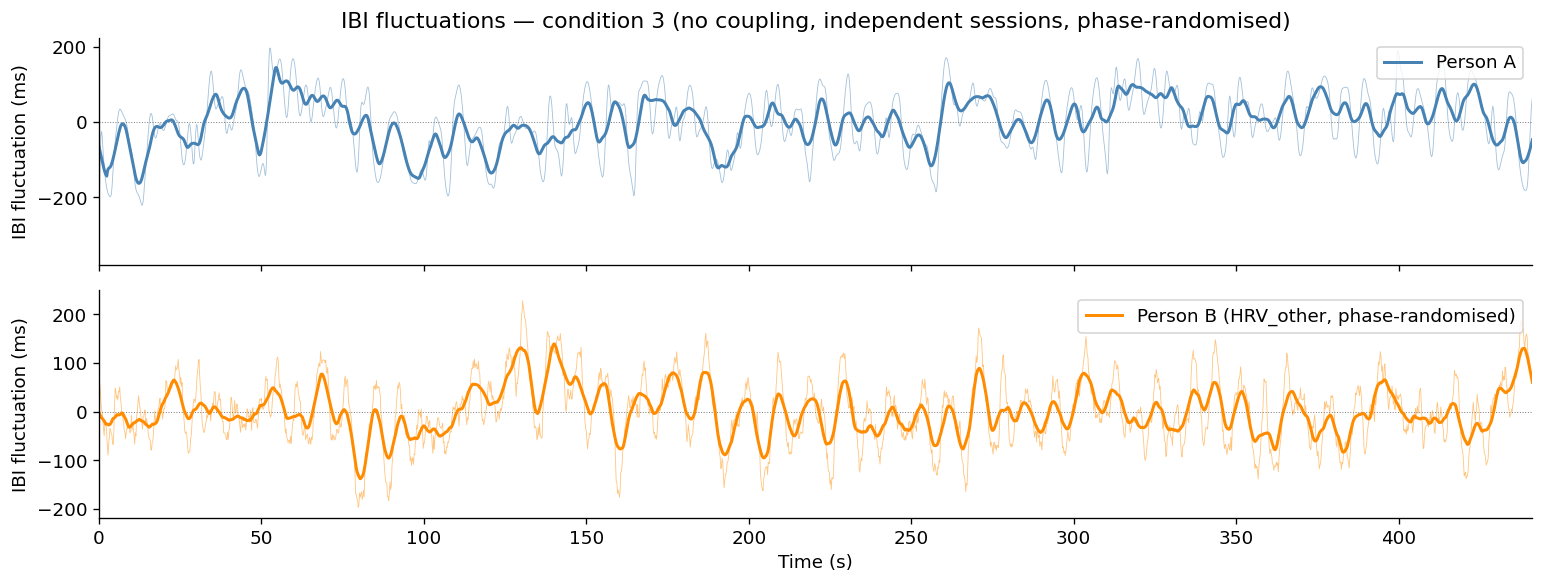

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

for ax in axes:
    ax.axhline(0, color='gray', lw=0.6, linestyle=':')

axes[0].plot(t_a, x_a_fluct,         lw=0.5, color='steelblue',  alpha=0.5)
axes[0].plot(t_a, smooth(x_a_fluct), lw=1.8, color='steelblue',  label='Person A')
axes[0].set_ylabel('IBI fluctuation (ms)')
axes[0].set_title('IBI fluctuations — condition 3 (no coupling, independent sessions, phase-randomised)')
axes[0].legend(loc='upper right')

axes[1].plot(t_a, x_b_fluct_c3,         lw=0.5, color='darkorange', alpha=0.5)
axes[1].plot(t_a, smooth(x_b_fluct_c3), lw=1.8, color='darkorange', label='Person B (HRV_other, phase-randomised)')
axes[1].set_ylabel('IBI fluctuation (ms)')
axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right')

for ax in axes:
    ax.set_xlim(0, t_a[-1])

plt.tight_layout()
plt.show()

### Cross-correlation and rolling correlation of fluctuations

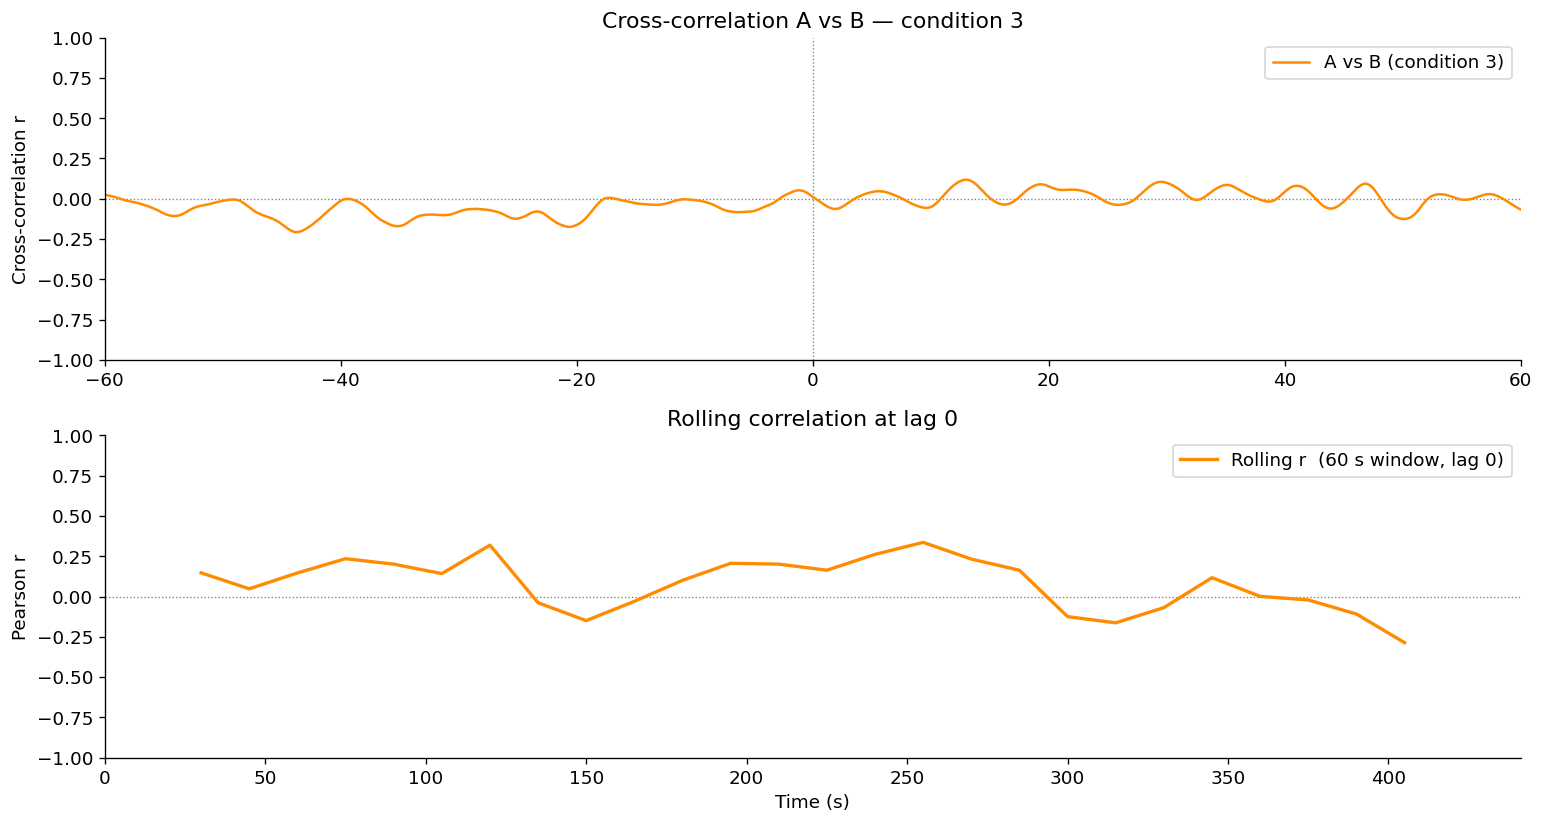

Mean rolling r = 0.078  |  SD = 0.160


In [22]:
# ── Cross-correlation at all lags ──────────────────────────────────────
xa_z3 = (x_a_fluct - x_a_fluct.mean()) / x_a_fluct.std()
xb_z3 = (x_b_fluct_c3 - x_b_fluct_c3.mean()) / x_b_fluct_c3.std()

cc_c3      = correlate(xa_z3, xb_z3, mode='full') / N
cc_c3_trim = cc_c3[mid - max_lag_n : mid + max_lag_n + 1]

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# top: cross-correlation
axes[0].axhline(0, color='gray', lw=0.8, linestyle=':')
axes[0].axvline(0, color='gray', lw=0.8, linestyle=':')
axes[0].plot(lags_trim, cc_c3_trim, lw=1.5, color='darkorange', label='A vs B (condition 3)')
axes[0].set_ylabel('Cross-correlation r')
axes[0].set_xlim(-MAX_LAG_S, MAX_LAG_S)
axes[0].set_ylim(-1, 1)
axes[0].set_title('Cross-correlation A vs B — condition 3')
axes[0].legend()

# bottom: rolling correlation at lag 0
centers_c3, rs_c3 = [], []
for start in range(0, N - win_n, step_n):
    end = start + win_n
    r = np.corrcoef(x_a_fluct[start:end], x_b_fluct_c3[start:end])[0, 1]
    centers_c3.append(t_a[start + win_n // 2])
    rs_c3.append(r)
centers_c3 = np.array(centers_c3)
rs_c3      = np.array(rs_c3)

axes[1].axhline(0, color='gray', lw=0.8, linestyle=':')
axes[1].plot(centers_c3, rs_c3, lw=2.0, color='darkorange',
             label=f'Rolling r  ({WIN_S} s window, lag 0)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Pearson r')
axes[1].set_ylim(-0.6, 0.6)
axes[1].set_xlim(0, t_a[-1])
axes[1].set_ylim(-1, 1)
axes[1].set_title('Rolling correlation at lag 0')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean rolling r = {rs_c3.mean():.3f}  |  SD = {rs_c3.std():.3f}')

In [23]:
ibi_a_c3 = uniform_to_ibi(t_a, x_a_c3)
ibi_b_c3 = uniform_to_ibi(t_a, x_b_c3)

for label, ibi in [('A', ibi_a_c3), ('B', ibi_b_c3)]:
    dur = ibi.sum() / 1000
    print(f'Person {label} (event-based):  n = {len(ibi)} beats  '
          f'| mean = {ibi.mean():.1f} ms  '
          f'| SD = {ibi.std():.1f} ms  '
          f'| duration = {dur:.0f} s ({dur/60:.1f} min)')

save_condition(ibi_a_c3, ibi_b_c3, 'cond3_no_coupling')

Person A (event-based):  n = 539 beats  | mean = 817.1 ms  | SD = 84.6 ms  | duration = 440 s (7.3 min)
Person B (event-based):  n = 619 beats  | mean = 711.5 ms  | SD = 66.5 ms  | duration = 440 s (7.3 min)
Saved → dyads_simulated/cond3_no_coupling/HRV_A.xlsx  (539 beats)
Saved → dyads_simulated/cond3_no_coupling/HRV_B.xlsx  (619 beats)
